# 🐍 Snake Game with Reinforcement Learning (DQN)

This notebook implements a Snake game and trains an AI agent using Deep Q-Networks (DQN) to play it.

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
from IPython.display import display, clear_output

print('All imports successful!')

All imports successful!


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Snake Game Environment

In [ ]:
class SnakeGame:
    """Snake game environment."""
    
    DIRECTIONS = {
        0: (-1, 0),  # up
        1: (1, 0),   # down
        2: (0, -1),  # left
        3: (0, 1),   # right
    }

    def __init__(self, grid_size=10, max_steps=None):
        self.grid_size = grid_size
        self.max_steps = max_steps or grid_size * grid_size * 2
        self.reset()

    def reset(self):
        mid = self.grid_size // 2
        self.snake = [(mid, mid), (mid, mid - 1), (mid, mid - 2)]
        self.direction = 3  # right
        self.food = self._place_food()
        self.score = 0
        self.steps = 0
        self.done = False
        return self._get_state()

    def _place_food(self):
        while True:
            pos = (random.randint(0, self.grid_size - 1),
                   random.randint(0, self.grid_size - 1))
            if pos not in self.snake:
                return pos

    def _get_state(self):
        head = self.snake[0]
        point_l = (head[0], head[1] - 1)
        point_r = (head[0], head[1] + 1)
        point_u = (head[0] - 1, head[1])
        point_d = (head[0] + 1, head[1])

        dir_l = self.direction == 2
        dir_r = self.direction == 3
        dir_u = self.direction == 0
        dir_d = self.direction == 1

        state = [
            # Danger straight
            (dir_r and self._is_collision(point_r)) or
            (dir_l and self._is_collision(point_l)) or
            (dir_u and self._is_collision(point_u)) or
            (dir_d and self._is_collision(point_d)),

            # Danger right
            (dir_u and self._is_collision(point_r)) or
            (dir_d and self._is_collision(point_l)) or
            (dir_l and self._is_collision(point_u)) or
            (dir_r and self._is_collision(point_d)),

            # Danger left
            (dir_d and self._is_collision(point_r)) or
            (dir_u and self._is_collision(point_l)) or
            (dir_r and self._is_collision(point_u)) or
            (dir_l and self._is_collision(point_d)),

            # Move direction
            dir_l, dir_r, dir_u, dir_d,

            # Food location
            self.food[0] < head[0],  # food up
            self.food[0] > head[0],  # food down
            self.food[1] < head[1],  # food left
            self.food[1] > head[1],  # food right
        ]
        return np.array(state, dtype=int)

    def _is_collision(self, point):
        if point[0] < 0 or point[0] >= self.grid_size or \
           point[1] < 0 or point[1] >= self.grid_size:
            return True
        if point in self.snake:
            return True
        return False

    def step(self, action):
        # action: 0=straight, 1=right turn, 2=left turn
        # Correct turn mappings: up=0, down=1, left=2, right=3
        # right_turn maps current direction -> new direction after a right turn
        right_turn = [3, 2, 0, 1]
        # left_turn maps current direction -> new direction after a left turn
        left_turn = [2, 3, 1, 0]
        if action == 1:  # right turn
            self.direction = right_turn[self.direction]
        elif action == 2:  # left turn
            self.direction = left_turn[self.direction]

        head = self.snake[0]
        move = self.DIRECTIONS[self.direction]
        new_head = (head[0] + move[0], head[1] + move[1])

        self.steps += 1
        reward = 0

        if self._is_collision(new_head) or self.steps > self.max_steps:
            self.done = True
            reward = -10
            return self._get_state(), reward, self.done

        self.snake.insert(0, new_head)

        if new_head == self.food:
            self.score += 1
            reward = 10
            self.food = self._place_food()
        else:
            self.snake.pop()
            reward = 0

        return self._get_state(), reward, self.done

    def render(self, ax=None):
        if ax is None:
            _, ax = plt.subplots(figsize=(5, 5))
        ax.clear()
        ax.set_xlim(0, self.grid_size)
        ax.set_ylim(0, self.grid_size)
        ax.set_xticks([])
        ax.set_yticks([])

        for x, y in self.snake:
            rect = patches.Rectangle((y, x), 1, 1, facecolor='#2ecc71', edgecolor='#27ae60')
            ax.add_patch(rect)

        head = self.snake[0]
        rect = patches.Rectangle((head[1], head[0]), 1, 1, facecolor='#1a8a3f', edgecolor='#27ae60')
        ax.add_patch(rect)

        fx, fy = self.food
        circle = patches.Circle((fy + 0.5, fx + 0.5), 0.4, facecolor='#e74c3c', edgecolor='#c0392b')
        ax.add_patch(circle)

        ax.set_title(f'Score: {self.score}')
        plt.tight_layout()

## 2. Deep Q-Network Model

In [4]:
class DQN(nn.Module):
    """Deep Q-Network."""

    def __init__(self, input_size=11, hidden_size=256, output_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        return self.net(x)

## 3. Replay Buffer

In [5]:
class ReplayBuffer:
    """Experience replay buffer."""

    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)).to(device),
            torch.LongTensor(actions).unsqueeze(1).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.FloatTensor(np.array(next_states)).to(device),
            torch.FloatTensor(dones).to(device),
        )

    def __len__(self):
        return len(self.buffer)

## 4. DQN Agent

In [6]:
class DQNAgent:
    """DQN agent for playing Snake."""

    def __init__(self, state_size=11, action_size=3, lr=1e-3, gamma=0.9,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                 batch_size=64, target_update=10):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update = target_update

        self.policy_net = DQN(state_size, output_size=action_size).to(device)
        self.target_net = DQN(state_size, output_size=action_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer()
        self.step_count = 0

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.policy_net(state_t)
            return q_values.argmax().item()

    def train(self):
        if len(self.memory) < self.batch_size:
            return 0.0

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        q_values = self.policy_net(states).gather(1, actions)
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1, keepdim=True)[0]
            targets = rewards.unsqueeze(1) + self.gamma * next_q * (1 - dones.unsqueeze(1))

        loss = F.mse_loss(q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        return loss.item()

## 5. Training Loop

In [7]:
def train_agent(episodes=1000, grid_size=10, render_every=100):
    env = SnakeGame(grid_size=grid_size)
    agent = DQNAgent()

    scores = []
    losses = []
    avg_scores = []

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    for ep in range(1, episodes + 1):
        state = env.reset()
        total_reward = 0
        ep_losses = []

        while True:
            action = agent.act(state)
            next_state, reward, done = env.step(action)
            agent.memory.push(state, action, reward, next_state, done)
            loss = agent.train()
            if loss > 0:
                ep_losses.append(loss)
            state = next_state
            total_reward += reward
            if done:
                break

        scores.append(env.score)
        avg_score = np.mean(scores[-100:])
        avg_scores.append(avg_score)
        if ep_losses:
            losses.append(np.mean(ep_losses))

        if ep % 10 == 0:
            print(f'Ep {ep:4d} | Score: {env.score:2d} | Avg(100): {avg_score:.2f} | '
                  f'Epsilon: {agent.epsilon:.3f} | Loss: {losses[-1] if losses else 0:.4f}')

        if ep % render_every == 0:
            clear_output(wait=True)
            ax1.clear()
            ax1.plot(scores, alpha=0.4, label='Score')
            ax1.plot(avg_scores, 'r-', linewidth=2, label='Avg (100)')
            ax1.set_xlabel('Episode')
            ax1.set_ylabel('Score')
            ax1.legend()
            ax1.set_title(f'Training Progress (Ep {ep})')

            ax2.clear()
            ax2.plot(losses, 'g-', alpha=0.6)
            ax2.set_xlabel('Episode')
            ax2.set_ylabel('Loss')
            ax2.set_title('DQN Loss')

            plt.tight_layout()
            display(fig)
            clear_output(wait=True)

    plt.close()
    return agent, scores, avg_scores, losses


print('Training function defined!')

Training function defined!


## 6. Run Training

Adjust `episodes` for longer/shorter training.

Ep  460 | Score:  9 | Avg(100): 14.79 | Epsilon: 0.010 | Loss: 7.0026
Ep  470 | Score: 21 | Avg(100): 14.65 | Epsilon: 0.010 | Loss: 7.0390
Ep  480 | Score:  7 | Avg(100): 14.87 | Epsilon: 0.010 | Loss: 6.4156


KeyboardInterrupt: 

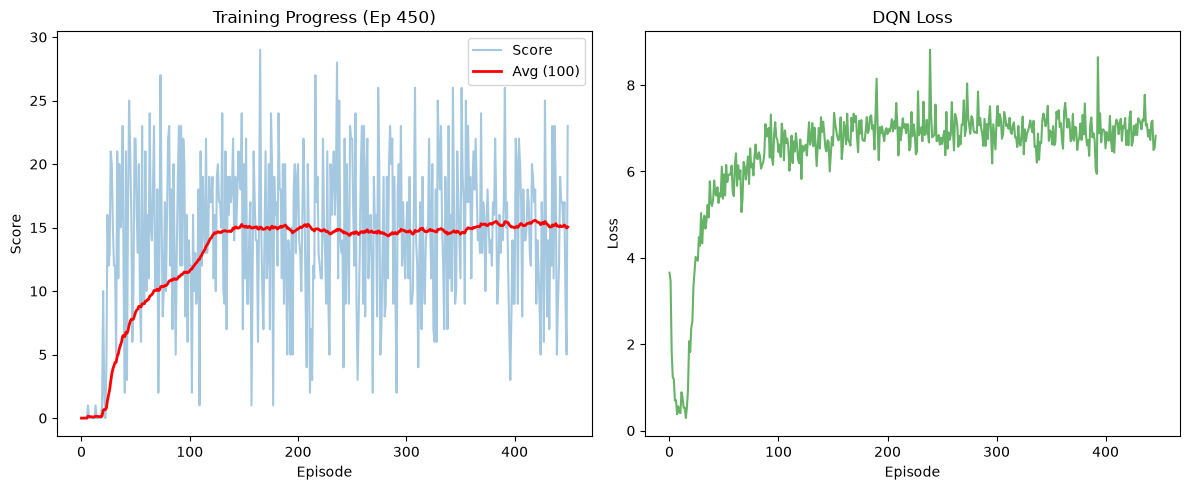

In [8]:
EPISODES = 1000
GRID_SIZE = 10

agent, scores, avg_scores, losses = train_agent(
    episodes=EPISODES,
    grid_size=GRID_SIZE,
    render_every=50
)

## 7. Final Performance Plot

In [ ]:
# Make sure training has been completed
if 'scores' not in locals():
    print("Error: Please run the training cell (CELL INDEX: 14) first!")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(scores, alpha=0.3, label='Score')
    ax1.plot(avg_scores, 'r-', linewidth=2, label='Avg (100)')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Score')
    ax1.set_title(f'Training Scores ({EPISODES} episodes)')
    ax1.legend()
    ax1.grid(alpha=0.3)

    if 'losses' in locals():
        if losses:
            ax2.plot(losses, 'g-', alpha=0.6)
        else:
            print("Warning: No losses recorded. Training may not have completed.")
    else:
        print("Warning: 'losses' is not defined. Please run the training cell (CELL INDEX: 14) first.")
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Loss')
    ax2.set_title('DQN Loss')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'Final avg score (last 100): {np.mean(scores[-100:]):.2f}')
    print(f'Best score: {max(scores)}')

Error: Please run the training cell (CELL INDEX: 14) first!


C:\Users\L10\AppData\Local\Temp\ipykernel_1892\1482482510.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


<Figure size 640x480 with 0 Axes>

NameError: name 'scores' is not defined

## 8. Watch the Trained Agent Play

In [26]:
def watch_agent(agent, grid_size=10, delay=0.3):
    env = SnakeGame(grid_size=grid_size)
    state = env.reset()
    agent.epsilon = 0  # greedy

    fig, ax = plt.subplots(figsize=(5, 5))

    while True:
        action = agent.act(state)
        state, _, done = env.step(action)

        env.render(ax)
        display(fig)
        clear_output(wait=True)
        time.sleep(delay)

        if done:
            break

    env.render(ax)
    display(fig)
    clear_output(wait=True)
    print(f'Final Score: {env.score}')
    plt.close()


watch_agent(agent, grid_size=GRID_SIZE, delay=0.2)

Final Score: 0


## 9. Save & Load Model

In [18]:
torch.save(agent.policy_net.state_dict(), 'snake_dqn.pth')
print('Model saved as snake_dqn.pth')

Model saved as snake_dqn.pth


In [25]:
# To load later:
agent = DQNAgent()
agent.policy_net.load_state_dict(torch.load('snake_dqn.pth', map_location=device))
agent.target_net.load_state_dict(agent.policy_net.state_dict())
print('Model loaded!')

Model loaded!
